In [403]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Problem 1: House Price Prediction using Gradient Descent


## Load Dataset

In [404]:
df = kagglehub.dataset_load( KaggleDatasetAdapter.PANDAS, "yasserh/housing-prices-dataset", "Housing.csv")
df.head()

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Convert to Numpy

In [405]:
X = df['area'].values
y = df['price'].values

X_norm = (X - np.mean(X)) / np.std(X)
y_norm = (y - np.mean(y)) / np.std(y)

## Implement the Mean Squared Error (MSE) Cost Function manually

In [406]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0.0

    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        cost += error ** 2

    return cost / (2*m)

## Gradient calculation function

In [407]:
def calculate_gradient(X, y, w, b):
    m = X.shape[0]
    dj_dw = 0.0
    dj_db = 0.0

    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]

        dj_dw += (error * X[i])
        dj_db += error


    return dj_dw/m, dj_db/m

### Apply Gradient Descent

In [408]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
    w = w_input
    b = b_input

    cost_history = []
    iteration_list = []

    for i in range(max_iter):
        dj_dw, dj_db = calculate_gradient(X, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db

        cost = compute_cost(X, y, w, b)

        cost_history.append(cost)
        iteration_list.append(i)

        if i%100 == 0:
            print(f"iteration : {i} w : {w: 0.4f}, b : {b: 0.4f}, dj_dw : {dj_dw: 0.4f}, dj_db : {dj_db: 0.4f}, cost : {cost: 0.4f}")

    return w, b, cost_history, iteration_list

## Prediciton

In [409]:
def make_prediction(X, y, w, b):
    m = X.shape[0]
    pred_list = np.zeros(m)

    for i in range(m):
        pred_list[i] = w * X[i] + b

    return pred_list

In [410]:
iterations = 2000
learning_rate = 0.01


w_final, b_final, cost_history, iter_history = gradient_descent(X_norm, y_norm, w, b, max_iter=iterations, alpha=learning_rate)

print(w_final, b_final)

iteration : 0 w :  0.0054, b : -0.0000, dj_dw : -0.5360, dj_db :  0.0000, cost :  0.4971
iteration : 100 w :  0.3418, b :  0.0000, dj_dw : -0.1962, dj_db : -0.0000, cost :  0.3752
iteration : 200 w :  0.4649, b :  0.0000, dj_dw : -0.0718, dj_db :  0.0000, cost :  0.3589
iteration : 300 w :  0.5100, b :  0.0000, dj_dw : -0.0263, dj_db : -0.0000, cost :  0.3567
iteration : 400 w :  0.5265, b :  0.0000, dj_dw : -0.0096, dj_db : -0.0000, cost :  0.3564
iteration : 500 w :  0.5325, b :  0.0000, dj_dw : -0.0035, dj_db :  0.0000, cost :  0.3564
iteration : 600 w :  0.5347, b :  0.0000, dj_dw : -0.0013, dj_db : -0.0000, cost :  0.3564
iteration : 700 w :  0.5355, b :  0.0000, dj_dw : -0.0005, dj_db : -0.0000, cost :  0.3564
iteration : 800 w :  0.5358, b :  0.0000, dj_dw : -0.0002, dj_db : -0.0000, cost :  0.3564
iteration : 900 w :  0.5359, b :  0.0000, dj_dw : -0.0001, dj_db : -0.0000, cost :  0.3564
iteration : 1000 w :  0.5360, b :  0.0000, dj_dw : -0.0000, dj_db : -0.0000, cost :  0.3564


In [411]:
prediction = make_prediction(X_norm, y_norm, w_final, b_final)

Text(0.5, 1.0, 'COST: 0.356353422659427, for w = 0.5359973447791114 and b = 2.778531737005009e-16')

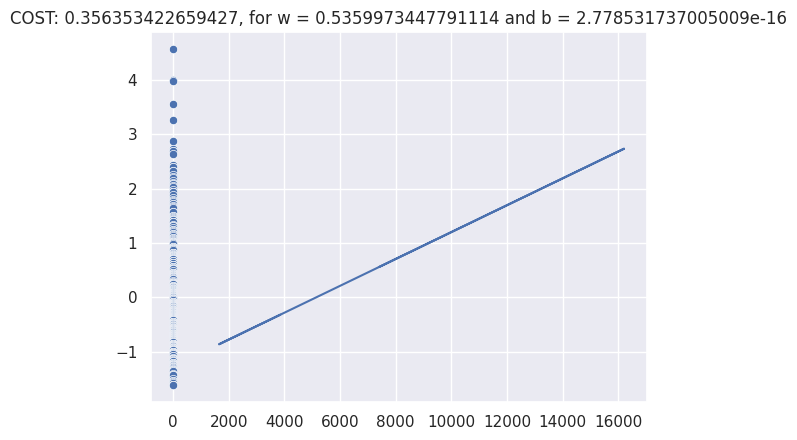

In [412]:
sns.scatterplot(x=X_norm, y=y_norm)
plt.plot(X, prediction)


plt.title(f"COST: {compute_cost(X_norm, y_norm, w=w_final, b=b_final)}, for w = {w_final} and b = {b_final}")

# Problem 2: Student Performance Prediction


In [413]:
df = kagglehub.dataset_load( KaggleDatasetAdapter.PANDAS, "spscientist/students-performance-in-exams", "StudentsPerformance.csv")
df.head()

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


--- Starting Gradient Descent ---
Iteration   0: Cost = 0.3665 | w = 0.4971, b = -0.1369
Iteration  50: Cost = 0.3601 | w = 0.5125, b = -0.0828
Iteration 100: Cost = 0.3577 | w = 0.5218, b = -0.0501
Iteration 150: Cost = 0.3568 | w = 0.5274, b = -0.0303
Iteration 200: Cost = 0.3565 | w = 0.5308, b = -0.0183
Iteration 250: Cost = 0.3564 | w = 0.5328, b = -0.0111
Iteration 300: Cost = 0.3564 | w = 0.5341, b = -0.0067
Iteration 350: Cost = 0.3564 | w = 0.5348, b = -0.0041
Iteration 400: Cost = 0.3564 | w = 0.5353, b = -0.0025
Iteration 450: Cost = 0.3564 | w = 0.5356, b = -0.0015
--- Finished! Final Cost: 0.3564 ---



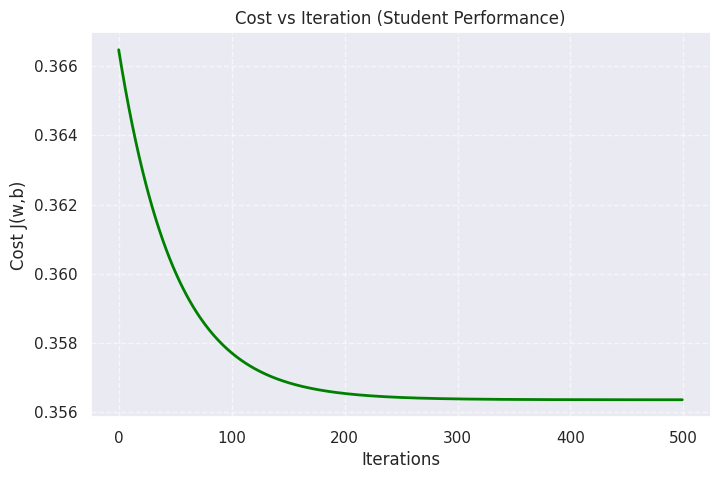

In [414]:
def gradient_descent_students(X, y, w_input, b_input, max_iter, alpha=0.01):
    w = w_input
    b = b_input
    cost_history = []
    iteration_list = []

    for i in range(max_iter):
        dj_dw, dj_db = calculate_gradient(X, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db

        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)
        iteration_list.append(i)

        # Task 5: Print cost every 50 iterations
        if i % 50 == 0:
            print(f"Iteration {i:3d}: Cost = {cost:.4f} | w = {w:.4f}, b = {b:.4f}")

    return w, b, cost_history, iteration_list

# Initialize random parameters
np.random.seed(42)
w_init = np.random.randn()
b_init = np.random.randn()

iterations = 500
learning_rate = 0.01

print("--- Starting Gradient Descent ---")
w_final, b_final, cost_history, iter_history = gradient_descent_students(
    X_norm, y_norm, w_init, b_init, max_iter=iterations, alpha=learning_rate
)
print(f"--- Finished! Final Cost: {cost_history[-1]:.4f} ---\n")

# ---------------------------------------------------------
# Task 6: Plot Cost vs Iteration
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(iter_history, cost_history, color='green', linewidth=2)
plt.title('Cost vs Iteration (Student Performance)')
plt.xlabel('Iterations')
plt.ylabel('Cost J(w,b)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Problem 3: Insurance Charges Prediction


In [415]:
df = kagglehub.dataset_load( KaggleDatasetAdapter.PANDAS, "mirichoi0218/insurance", "insurance.csv")
df.head()

Using Colab cache for faster access to the 'insurance' dataset.


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [416]:
X = df['age'].values
y = df['charges'].values

X_norm = (X - np.mean(X)) / np.std(X)
y_norm = (y - np.mean(y)) / np.std(y)

In [417]:
def compute_cost(X, y, w, b):
    m = X.shape[0]

    cost = 0.0

    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        cost += (error ** 2)

    return cost / (2 * m)


def calculate_gradient(X, y, w, b):
    m = X.shape[0]

    dj_dw = 0.0
    dj_db = 0.0
    error = 0.0

    for i in range(m):
        prediction = w * X[i] + b
        error += (prediction - y[i])

        dj_dw += (error * X[i])
        dj_db += error

    return dj_dw/m , dj_db/m

def gradient_descent_insurance(X, y, w_input, b_input, max_iter, alpha=0.01):
    w = w_input
    b = b_input

    for i in range(max_iter):
        dj_dw, dj_db = calculate_gradient(X, y, w, b)

        w -= alpha * dj_dw
        b -= alpha * dj_db




        if i%100 == 0:
            print(f"iteration : {i} w : {w: 0.4f}, b : {b: 0.4f}, dj_dw : {dj_dw: 0.4f}, dj_db : {dj_db: 0.4f}, cost : {cost: 0.4f}")

    return w, b




--- Starting Training ---
Initial Cost (before training): 0.5000

iteration : 0 w :  0.0050, b :  0.0130, dj_dw : -0.5020, dj_db : -1.3027, cost :  0.4986
iteration : 100 w : -691342500665469756804269072096051203818109728471286546494669723241807872.0000, b :  38040969002781464148176531306178121220862642810371184953122631310534246400.0000, dj_dw :  81278424731582173962203662215390468562486803599808955184638503240421343232.0000, dj_db : -4472327439485967264459571617820524970631206694369866173407116470712207933440.0000, cost :  723796638561901726008175215752824604115002285178411976791430548763210776838638713207236633128269094521360051418476498351670371196028379890827919360.0000
iteration : 200 w : -2356233830302329274732337803057339308896985099533086618932815128655401063505779150764366472664344491907790286330539242192287141116220070999818764288.0000, b :  129651248137583827792617285029964835312951856327343286321090813675772677904661128472891254261136912785929952681639712000422210675244710

/tmp/ipykernel_5646/2411287799.py:9: RuntimeWarning: overflow encountered in scalar add
  cost += (error ** 2)
/tmp/ipykernel_5646/2411287799.py:9: RuntimeWarning: overflow encountered in scalar power
  cost += (error ** 2)


iteration : 300 w : -8030517229473314013545078461020087655950943626234060991434366333323243780163636333014570793685580425151321462550682943485206438966489628178479652916190450198511593069292767813312472057323538021586381047454507044263985938432.0000, b :  441877443826529237474335473164028612757526657841344167082409311110929151571285037444625466857892445504874303275298894631479919794485911943968062290284906140324660830537980524447243105197509623497876500675007735801323901157376.0000, dj_dw :  944116396088972343930062297268533340550760448042192246131254268589028249764411814533472837955954373631979423397609606554086152544771703483489679279174839569949213910319449100849721833699680350563633427252295793083677109387264.0000, dj_db : -51949796987842492532221654091088324465122102799721855093688569217991609015790795664044376253424357915699680016505297310730109219870017636341868330270983121129415105145040383698286717421178714668001486293140740145946143076909056.0000, cost :  inf
iteration : 400 

/tmp/ipykernel_5646/2411287799.py:26: RuntimeWarning: overflow encountered in scalar add
  dj_db += error
/tmp/ipykernel_5646/2411287799.py:25: RuntimeWarning: invalid value encountered in scalar add
  dj_dw += (error * X[i])
/tmp/ipykernel_5646/1640160425.py:11: RuntimeWarning: invalid value encountered in scalar subtract
  b -= alpha * dj_db


iteration : 600 w :  nan, b :  nan, dj_dw :  nan, dj_db :  nan, cost :  nan
iteration : 700 w :  nan, b :  nan, dj_dw :  nan, dj_db :  nan, cost :  nan
iteration : 800 w :  nan, b :  nan, dj_dw :  nan, dj_db :  nan, cost :  nan
iteration : 900 w :  nan, b :  nan, dj_dw :  nan, dj_db :  nan, cost :  nan

Final Cost (after 1000 iterations): nan


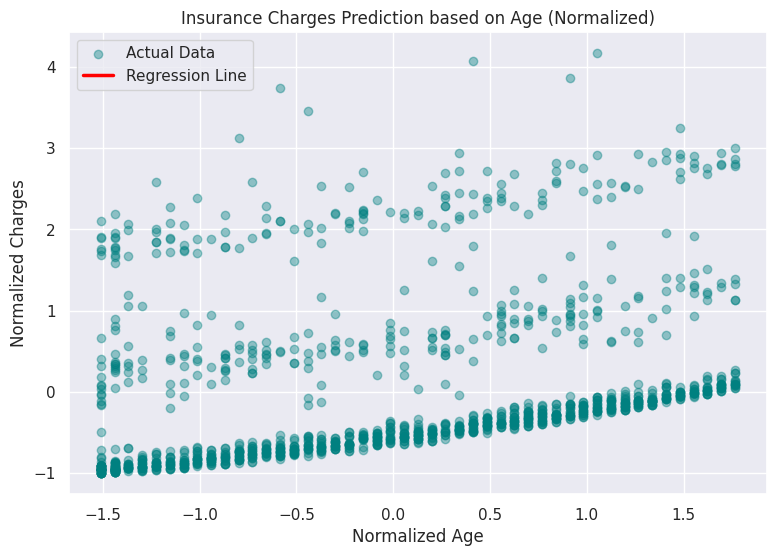

In [418]:
w_init, b_init = 0.0, 0.0
alpha = 0.01
iterations = 1000

print("--- Starting Training ---")
initial_cost = compute_cost(X_norm, y_norm, w_init, b_init)
print(f"Initial Cost (before training): {initial_cost:.4f}\n")

w_final, b_final, cost_history, iter_history  = gradient_descent(X_norm, y_norm, w_init, b_init, alpha=0.01, max_iter=iterations)

final_cost = compute_cost(X_norm, y_norm, w_final, b_final)
print(f"\nFinal Cost (after {iterations} iterations): {final_cost:.4f}")


predictions = (w_final * X_norm) + b_final

plt.figure(figsize=(9, 6))
plt.scatter(X_norm, y_norm, color='teal', alpha=0.4, label='Actual Data')
plt.plot(X_norm, predictions, color='red', linewidth=2.5, label='Regression Line')
plt.title('Insurance Charges Prediction based on Age (Normalized)')
plt.xlabel('Normalized Age')
plt.ylabel('Normalized Charges')
plt.legend()
plt.show()

#Problem 4: Salary Prediction


In [419]:
df = kagglehub.dataset_load( KaggleDatasetAdapter.PANDAS, "karthickveerakumar/salary-data-simple-linear-regression", "Salary_Data.csv")
df.head()

Using Colab cache for faster access to the 'salary-data-simple-linear-regression' dataset.


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [420]:
X = df["YearsExperience"].values
y = df['Salary'].values

X_norm = (X - np.mean(X)) / np.std(X)
y_norm = (y - np.mean(y)) / np.std(y)

In [421]:
w_init, 0.0
b_init = 0.0
initial_cost = compute_cost(X_norm, X_norm, w_init, b_init)

alpha = 0.01

iterations = 5000

print(f"Initial Cost : {initial_cost}")

w_final, b_final, cost_history, iter_history = gradient_descent(X_norm, y_norm, w_init, b_init, alpha=0.01, max_iter=iterations)


Initial Cost : 0.5
iteration : 0 w :  0.0044, b : -0.0832, dj_dw : -0.4426, dj_db :  8.3164, cost :  0.4991
iteration : 100 w :  0.9660, b : -0.0042, dj_dw :  0.0047, dj_db :  0.0035, cost :  0.0216
iteration : 200 w :  0.9655, b : -0.0047, dj_dw : -0.0000, dj_db : -0.0000, cost :  0.0216
iteration : 300 w :  0.9655, b : -0.0047, dj_dw : -0.0000, dj_db : -0.0000, cost :  0.0216
iteration : 400 w :  0.9655, b : -0.0047, dj_dw :  0.0000, dj_db :  0.0000, cost :  0.0216
iteration : 500 w :  0.9655, b : -0.0047, dj_dw : -0.0000, dj_db : -0.0000, cost :  0.0216
iteration : 600 w :  0.9655, b : -0.0047, dj_dw : -0.0000, dj_db : -0.0000, cost :  0.0216
iteration : 700 w :  0.9655, b : -0.0047, dj_dw : -0.0000, dj_db : -0.0000, cost :  0.0216
iteration : 800 w :  0.9655, b : -0.0047, dj_dw : -0.0000, dj_db : -0.0000, cost :  0.0216
iteration : 900 w :  0.9655, b : -0.0047, dj_dw : -0.0000, dj_db : -0.0000, cost :  0.0216
iteration : 1000 w :  0.9655, b : -0.0047, dj_dw : -0.0000, dj_db :  0.00

Text(0, 0.5, 'cost')

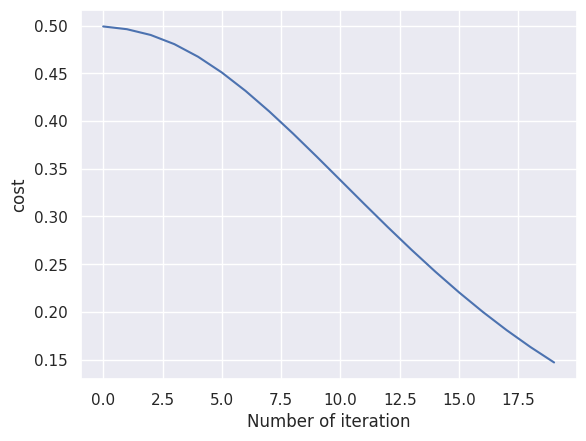

In [422]:
plt.plot(iter_history[:20], cost_history[:20])
plt.xlabel("Number of iteration")
plt.ylabel("cost")

Text(0.5, 1.0, 'COST: 3251017087.0151978, for w = 0.96548672891499 and b = -0.004697119005097178')

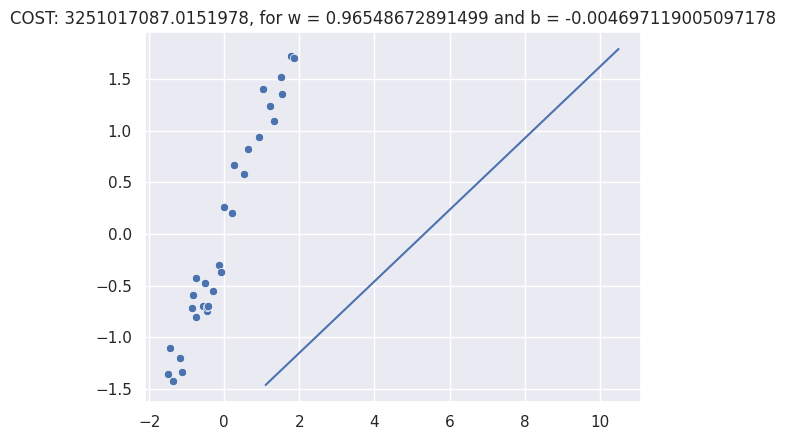

In [429]:
predictions = make_prediction(X_norm, y_norm, w_final, b_final)
sns.scatterplot(x=X_norm, y=y_norm)
plt.plot(X, predictions)


plt.title(f"COST: {compute_cost(X, y, w=w_final, b=b_final)}, for w = {w_final} and b = {b_final}")